<a href="https://colab.research.google.com/github/Dydak811/ConnectaTel-Analisis-Outliers-y-Patrones/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


### Comentario General Iteración #1
<div class="alert alert-block alert-danger">

Pasti, quería dejarte aquí una apreciación general de tu proyecto para que a partir de allí nos vayamos punto por punto.

Primero que nada, espero qu este camino en el mundo de los datos esté siendo muy interesante y lleno de aprendizajes significativos. Espero que lo disfrutes y puedas hacerte muchas preguntas que te lleven a analizar y ver los datos como si fueran historias, porque al final, ese es nuestro objetivo!

Respecto a tu trabajo en esta primera iteración, has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets. Sin embargo, se presentaron varios errores o puntos incompletos a lo largo del notebook. Te invito a revisar punto por punto y espero tu proxima entrega. Saludos!

---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")  # mejora visual

In [ ]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users =  pd.read_csv('/datasets/users_latam.csv') #completa el código
usage =  pd.read_csv('/datasets/usage.csv') #completa el código


In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [ ]:
usage[usage["user_id"] == 1000]

,id,user_id,type,date,duration,length


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Buen trabajo con la importación de las librerías y datasets requeridos, al igual que con los métodos para la exploración inicial de los datos.

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print( users.isna().sum())
print()# Cantidad de valores nulos)
print( users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
**la unica columna que parece tener nulos es "churn_date" ahora como representa menos del 1% de los datos segun el promedio entonces lo mejor es dejarlos como nulos. en cierto caso podrían remplazarse como el promedio de los datos sin embargo esta estrategia no afectaria significativamente el resultado y ademas al tratarse de valores en fecha no hay forma de rellenar con promedio**  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000




- La columna user_id presenta una distribución completamente uniforme y ordenada, con valores entre 1000 y 1499. La media (1249.5) coincide exactamente con la mediana (1249.5), lo que indica una distribución simétrica sin sesgo. La desviación estándar es relativamente baja y no hay evidencia de valores atípicos. Esto sugiere que se trata de un identificador secuencial y no de una variable analítica.


- La columna age muestra una distribución bastante equilibrada. La media (≈46.6) es muy cercana a la mediana (46), lo que indica que no existe un sesgo significativo. Los valores mínimo (18) y máximo (75) son razonables y no sugieren outliers extremos. Además, los cuartiles (32, 46, 62) están bien distribuidos, lo que refleja una dispersión moderada y un comportamiento típico de edades en una población adulta.




In [ ]:
# explorar columnas numéricas de
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas id y user_id
Corresponden a identificadores únicos, por lo que sus estadísticas descriptivas no aportan valor analítico. Aunque presentan distribuciones uniformes y sin anomalías, no son relevantes para el análisis del comportamiento de los datos.

- Las columnas duration y length
La columna duration presenta una media de aproximadamente 5.2 y una mediana de 3.5, lo que sugiere una ligera asimetría positiva (sesgo a la derecha), posiblemente influenciada por valores altos (máximo de 120).

- La columna length también muestra dispersión considerable, con una media de aproximadamente 52 y un valor máximo de 1490, muy superior al tercer cuartil (64), lo que indica la presencia de outliers significativos.

In [ ]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595



- La columna city presenta 76 valores únicos, lo que indica una alta diversidad geográfica de los usuarios. La ciudad más frecuente es "Moscú" con 99 registros, lo cual sugiere una mayor concentración de usuarios en esa ubicación.


- La columna tariff contiene únicamente 2 valores únicos, lo cual es consistente con la existencia de pocos planes disponibles. El plan más frecuente es "smart" con 351 usuarios, lo que indica que es el plan más contratado.




In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna type presenta 2 categorías y muestra que "text" es la más frecuente con 22,092 registros, lo que sugiere que este tipo de uso es el más común entre los usuarios.



---
✍️ **Comentario**: Se detectan valores de 0 en las columnas duration y length, que podrían representar datos inválidos o ausencia de uso.

Acción recomendada:
Validar si estos valores son correctos; en caso contrario, tratarlos como valores faltantes (NaN) para su análisis.



### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()



2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()



2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

**No se identifican años imposibles ni fuera del rango esperado (hasta 2024). Las fechas son coherentes con el periodo de registro de los datos.**

**Acción recomendada: No se requieren cambios. En caso de detectar fechas fuera de rango, se recomienda revisarlas y corregirlas o eliminarlas si son errores de captura.**

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Reconociste los valores nulos y atipicos en las columnas de los datasets. Hiciste un correcto cambio de formato a tipo fecha para las columnas y reconociste los años anomalos (que no serán necesarios para el analisis). Buen trabajo con el reconocimiento de los datos anomalos en el dataset `users`.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
age_median = users['age'].median()
users['age'] = users['age'].replace(-999, age_median)

# Verificar
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)

# Verificar
users['city'].isna().sum()

565

In [ ]:
# Marcar fechas futuras como NA para reg_date


users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
- Los valores nulos en duration y length dependen directamente de la variable type. Se observa que duration es nula casi en su totalidad para registros de tipo text, mientras que length es nula para registros de tipo call.
  

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente trabajo con los reemplazos de los valores atípicos de `age` y `city` del datset `users`. Igualmente la verificación de los MAR está correcta, como mencionas, tiene sentido que las proporciones varien segun el tipo ya que las llamadas no tienen un `lenght` y los mensajes no tienen `duration`.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
usage['is_text'] = (usage['type'] == 'text').astype(int)
usage['is_call'] = (usage['type'] == 'call').astype(int)

usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

print(usage_agg.head())
print(len(set(users['user_id']).intersection(set(usage_agg['user_id']))))

   user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
0    10000              7              3                 23.70
1    10001              5             10                 33.18
2    10002              5              2                 10.74
3    10003             11              3                  8.99
4    10004              4              3                  8.01
3999


In [ ]:
# Renombrar columnas


usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
}, inplace=True)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
len(set(users['user_id']).intersection(set(usage_agg['user_id'])))

3999

In [ ]:




# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)
user_profile.head(5)






,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


# Pruebas --------------------------------------------------------------------------------------

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:

# Seleccionar columnas numéricas
numeric_cols = user_profile.select_dtypes(include=['int64', 'float64']).columns

print(numeric_cols)

numeric_cols = user_profile.select_dtypes(include=['int64', 'float64']).columns

print("Resumen estadístico:")
print(user_profile[numeric_cols].describe())

print("\nMedianas:")
print(user_profile[numeric_cols].median())

Index(['user_id', 'age', 'cant_mensajes', 'cant_llamadas',
       'cant_minutos_llamada'],
      dtype='object')
Resumen estadístico:
            user_id          age  cant_mensajes  cant_llamadas  \
count   4000.000000  4000.000000    3999.000000    3999.000000   
mean   11999.500000    48.122250       5.524381       4.478120   
std     1154.844867    17.690408       2.358416       2.144238   
min    10000.000000    18.000000       0.000000       0.000000   
25%    10999.750000    33.000000       4.000000       3.000000   
50%    11999.500000    47.000000       5.000000       4.000000   
75%    12999.250000    63.000000       7.000000       6.000000   
max    13999.000000    79.000000      17.000000      15.000000   

       cant_minutos_llamada  
count           3999.000000  
mean              23.317054  
std               18.168095  
min                0.000000  
25%               11.120000  
50%               19.780000  
75%               31.415000  
max              155.690000  



In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

La creación de la tabla auxiliar con el conteo de llamadas y mensajes por usuario está super bien, muy buen uso del filtrado, el agrupamiento con `groupby`. Sin embargo, observa que el `merge` está sacando un dataset con NaN, debes revisar esto porque va a impedir que los siguientes puntos sobre estas variables de cantidades se imposibiliten.  



---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

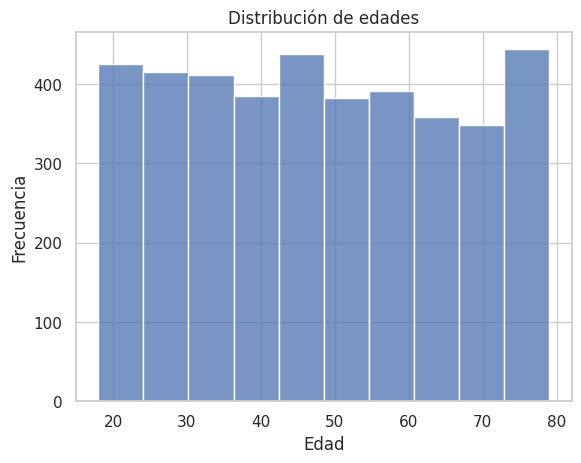

In [ ]:

# Histograma para visualizar la edad (age)

sns.histplot(user_profile['age'], bins=10)
plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


💡Insights:
- Distribución se podría decir que se nota un ligero
o sesgo a la derecha sin embargo el caso concuerda mucho mas con la distribucion normal pues sus datos se encuentran en intervalos parecidos sin sesgo extremo aparente.

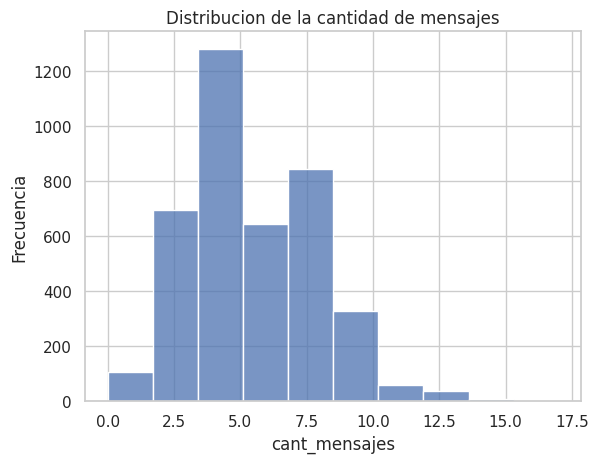

In [ ]:

# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile['cant_mensajes'], bins=10)
plt.title("Distribucion de la cantidad de mensajes")
plt.xlabel("cant_mensajes")
plt.ylabel("Frecuencia")
plt.show()


💡Insights:
- Cantidad_mensajes parece tener una media bastante elevada por lo que podria afectar el promedio

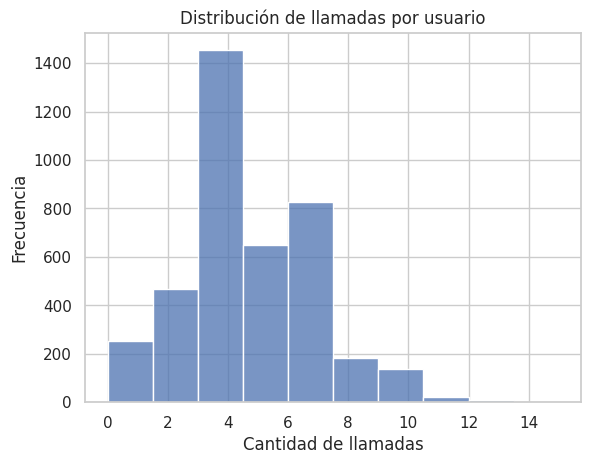

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile['cant_llamadas'].dropna(), bins=10)
plt.title("Distribución de llamadas por usuario")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights:
- Distribución con sesgo a la derecha con media afectada por outliers
-

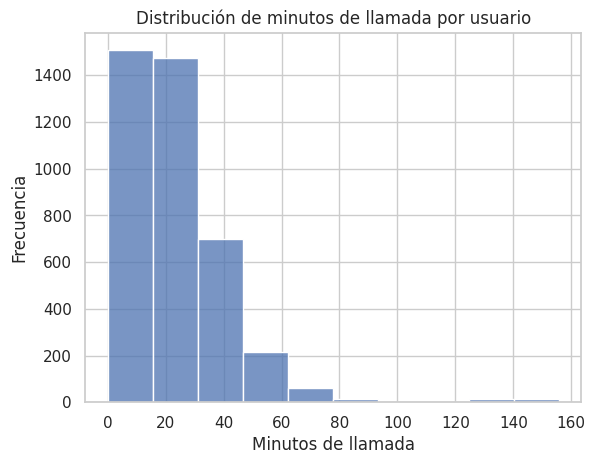

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile['cant_minutos_llamada'].dropna(), bins=10)
plt.title("Distribución de minutos de llamada por usuario")
plt.xlabel("Minutos de llamada")
plt.ylabel("Frecuencia")
plt.show()

💡Insights:
- Minutos de llamada tiene un gran sesgo a la derecha, en este caso no se debe confiar en la media si no en la mediana.

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Vas muy bien con la implementacion de los histogramas. Sin embargo, observa que estan quedando vacios y que en el primero no se ha realizado la diferenciacion entre planes propuesta en la tarea (recuerda que esto se hace con el argumento `hue='plan'`).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

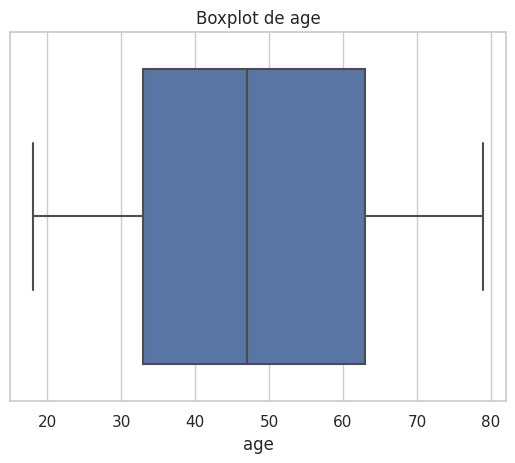

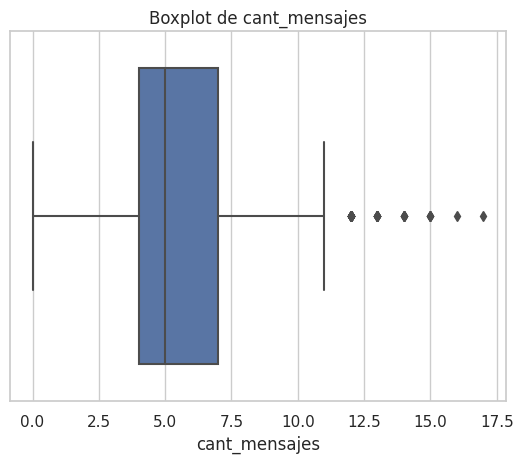

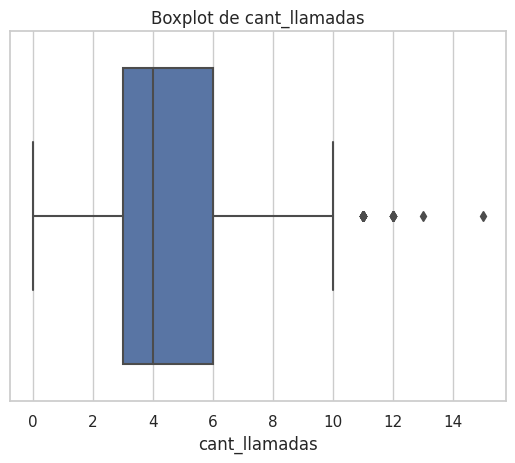

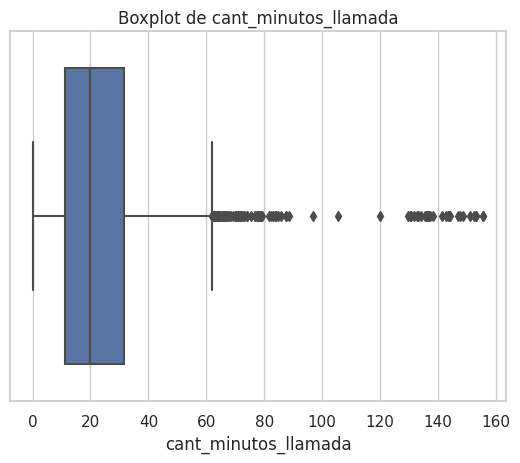

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:

    plt.figure()
    sns.boxplot(x=user_profile[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: no presenta outliers parece distribucion normal (presenta o no outliers)
- cant_mensajes: presenta ciertos outliers a la derecha concuerda con distribucion
- cant_llamadas: ...al igual que cant_mensajes presenta outliers y casos extremos en cantidades altas
- cant_minutos_llamada: ... estos datos presenta la mayor cantidad de outliers en todas las distribuciones.

In [ ]:
# Calcular límites con el método IQR

columnas_limites = ['cant_llamadas', 'cant_minutos_llamada', "cant_mensajes"]

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1

    print(f"\nColumna: {col}")
    print(f"Q1 (25%): {q1}")
    print(f"Q3 (75%): {q3}")
    print(f"IQR: {iqr}")


Columna: cant_llamadas
Q1 (25%): 3.0
Q3 (75%): 6.0
IQR: 3.0

Columna: cant_minutos_llamada
Q1 (25%): 11.12
Q3 (75%): 31.415
IQR: 20.295

Columna: cant_mensajes
Q1 (25%): 4.0
Q3 (75%): 7.0
IQR: 3.0


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_llamadas,cant_minutos_llamada,cant_mensajes
count,3999.000000,3999.000000,3999.000000
mean,4.478120,23.317054,5.524381
std,2.144238,18.168095,2.358416
min,0.000000,0.000000,0.000000
25%,3.000000,11.120000,4.000000
50%,4.000000,19.780000,5.000000
75%,6.000000,31.415000,7.000000
max,15.000000,155.690000,17.000000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? en todos los casos se recomienda no eliminar outliers pues no se tratan de errores de entrada o malos datos sin embargo si se recomienda winderizar ya que afectan con mayor problema los analisis
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

De nuevo observa que por los valores nulos que se presentan, todos los resultados están dando NaN.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:


def clasificar_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(row):
    edad = row['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

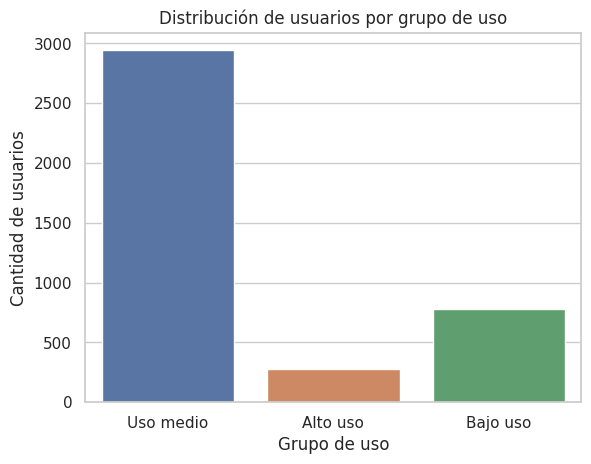

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(x='grupo_uso', data=user_profile)
plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

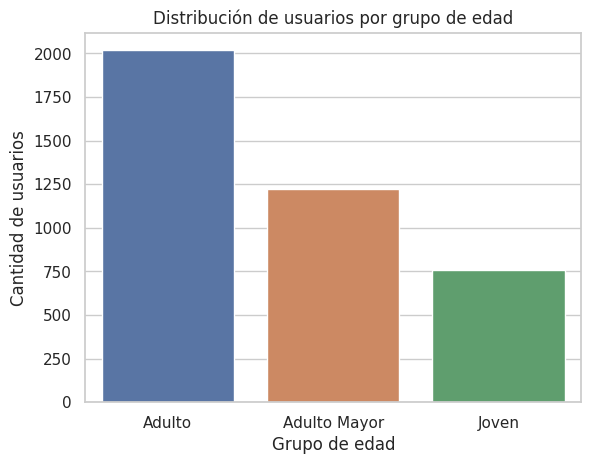

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(x='grupo_edad', data=user_profile)
plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente trabajo de segmentación por grupos con el filtrado por funciones con `.apply`y sus respectivos graficos.


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### 📊 Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Existe una **desproporción entre segmentos**, especialmente en el nivel de uso (muy pocos usuarios de alto uso).
- Se observa una **menor participación del segmento joven**, lo que puede indicar oportunidad de crecimiento o sesgo en adquisición.

---

🔍 **Segmentos por Edad**
- El grupo **Adulto es el predominante**, concentrando la mayor parte de usuarios.
- Los **Adultos Mayores** representan un segmento intermedio relevante.
- El segmento **Joven es el más pequeño**, lo que puede impactar el crecimiento futuro.

---

📊 **Segmentos por Nivel de Uso**
- La mayoría de los usuarios se ubican en **uso medio**, indicando engagement moderado.
- El **alto uso es muy bajo**, lo que sugiere poca conversión a usuarios intensivos.
- Existe un grupo relevante de **bajo uso**, con posible riesgo de abandono.

---

➡️ Esto sugiere que la base de usuarios es estable pero con **bajo nivel de engagement profundo**, y una oportunidad clara en **incrementar el uso y atraer segmentos más jóvenes**.

---

💡 **Recomendaciones**
- Impulsar estrategias para **convertir usuarios de uso medio a alto uso** (beneficios, personalización, incentivos).
- Diseñar campañas enfocadas en **captación de usuarios jóvenes**.
- Implementar acciones de **retención para usuarios de bajo uso**.
- Analizar el comportamiento de usuarios de **alto uso** para replicar patrones.


<div class="alert alert-block alert-danger">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

El resumen ejecutivo se encuentra incompleto aun. Te invito a realizar esta parte.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Recuerda que la creacion del repositorio en GitHub tambien es esencial como parte de tu aprendizaje. Realiza este punto para que te familiarices con ello, ánimo!